In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("cleaned_sales_data.csv")
df['order_date'] = pd.to_datetime(df['order_date'])

TOP PRODUCTS

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25528\628065756.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_products.values, y=top_products.index, palette=colors)


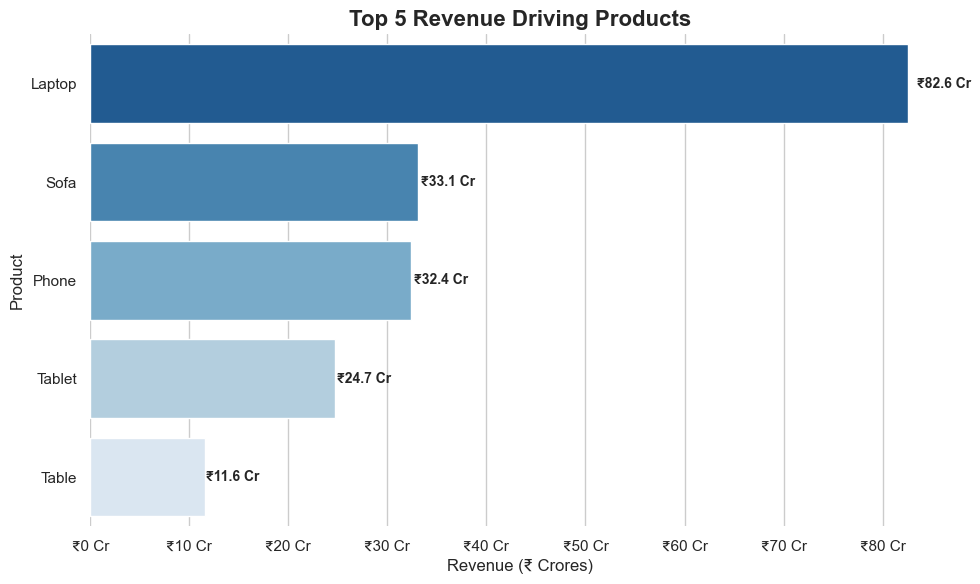

In [14]:
plt.figure(figsize=(10,6))

top_products = df.groupby('product')['sales'].sum().sort_values(ascending=False).head(5)

colors = sns.color_palette("Blues_r", len(top_products))

ax = sns.barplot(x=top_products.values, y=top_products.index, palette=colors)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'₹{int(x/1e7)} Cr'))

for i, v in enumerate(top_products.values):
    ax.text(v + (v*0.01), i, f"₹{v/1e7:.1f} Cr", va='center', fontsize=10, fontweight='bold')

plt.title("Top 5 Revenue Driving Products", fontsize=16, fontweight='bold')
plt.xlabel("Revenue (₹ Crores)")
plt.ylabel("Product")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

MONTHLY SALES TREND

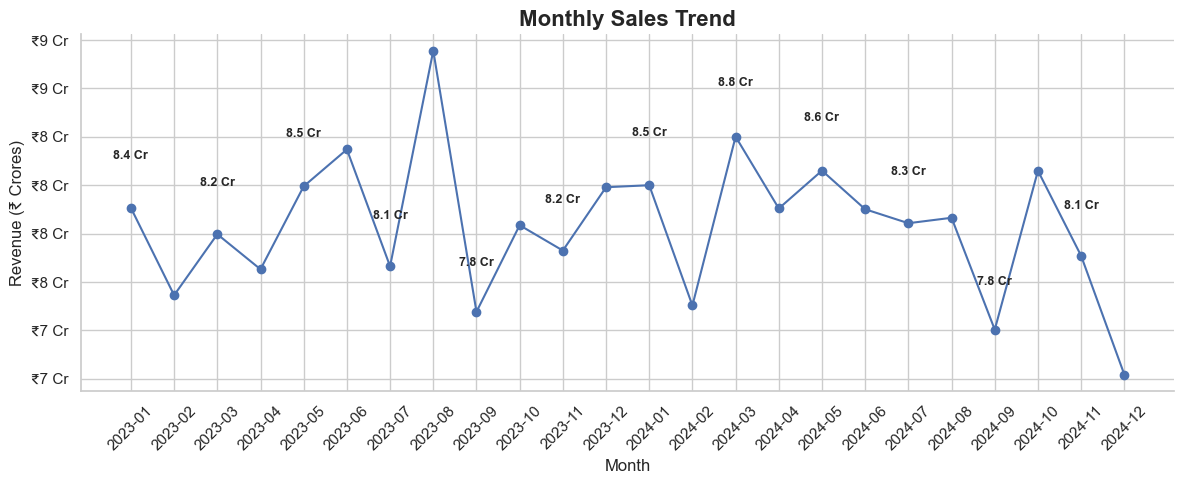

In [22]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales['month'], monthly_sales['sales'], marker='o')

# Format Y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'₹{int(x/1e7)} Cr'))

# ✅ CLEAN LABELS (every 2nd point → less clutter)
for i, v in enumerate(monthly_sales['sales']):
    if i % 2 == 0:   # 👈 only alternate points
        plt.text(
            i,
            v + (v * 0.03),
            f"{v/1e7:.1f} Cr",
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

plt.title("Monthly Sales Trend", fontsize=16, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Revenue (₹ Crores)")
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

REGION PERFORMANCE

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25528\2989400497.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=region_sales.values, y=region_sales.index, palette=colors)


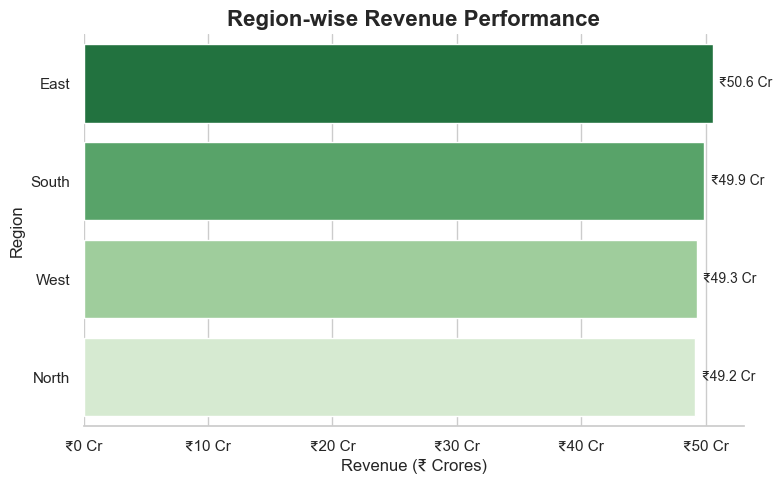

In [16]:
plt.figure(figsize=(8,5))

region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)

colors = sns.color_palette("Greens_r", len(region_sales))

ax = sns.barplot(x=region_sales.values, y=region_sales.index, palette=colors)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'₹{int(x/1e7)} Cr'))

for i, v in enumerate(region_sales.values):
    ax.text(v + (v*0.01), i, f"₹{v/1e7:.1f} Cr", va='center', fontsize=10)

plt.title("Region-wise Revenue Performance", fontsize=16, fontweight='bold')
plt.xlabel("Revenue (₹ Crores)")
plt.ylabel("Region")

sns.despine(left=True)
plt.tight_layout()
plt.show()

CATEGORY PERFORMANCE

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25528\292033085.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_sales.values, y=category_sales.index, palette=colors)


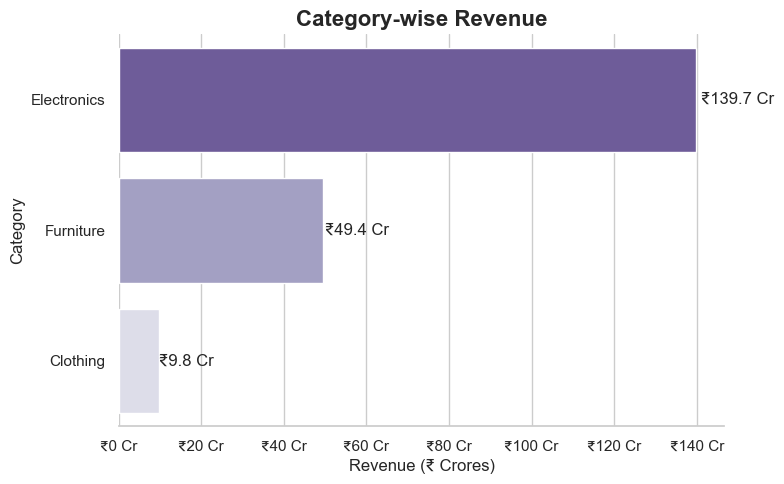

In [17]:
plt.figure(figsize=(8,5))

category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

colors = sns.color_palette("Purples_r", len(category_sales))

ax = sns.barplot(x=category_sales.values, y=category_sales.index, palette=colors)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'₹{int(x/1e7)} Cr'))

for i, v in enumerate(category_sales.values):
    ax.text(v + (v*0.01), i, f"₹{v/1e7:.1f} Cr", va='center')

plt.title("Category-wise Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Revenue (₹ Crores)")
plt.ylabel("Category")

sns.despine(left=True)
plt.tight_layout()
plt.show()

DISCOUNT vs PROFIT

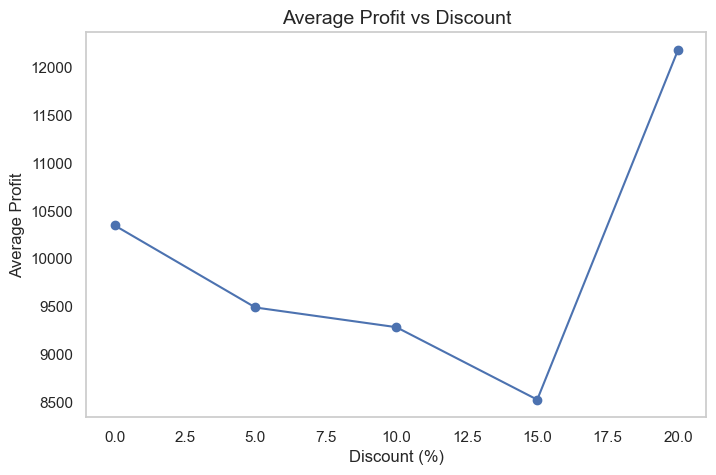

In [23]:
plt.figure(figsize=(8,5))

avg_profit = df.groupby('discount')['profit'].mean()

plt.plot(avg_profit.index, avg_profit.values, marker='o')

plt.title("Average Profit vs Discount", fontsize=14)
plt.xlabel("Discount (%)")
plt.ylabel("Average Profit")

plt.grid()
plt.show()